# Plotting Level 3 VIIRS SNPP Data
Goals:
> **Plot all the data from df</p>**
> **Plot data based on Julian Day** </p>
> **Plot data in a bar plot format**
***

In [2]:
pip install cmocean

  Using cached cmocean-4.0.3-py3-none-any.whl.metadata (4.2 kB)
Using cached cmocean-4.0.3-py3-none-any.whl (421 kB)
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import matplotlib.gridspec as gridspec
from datetime import datetime
import cmocean 

In [3]:
# original dataset
df = pd.read_csv(r'/home/jovyan/Desktop/newest datasets/VIIRS_timeseries_8D_2012-2025.csv')
df = df.drop(columns = 'Unnamed: 0')
df = df.rename(columns = {'end_date': 'end date', 'POC-a mean': 'POC mean'})
df['start date'], df['end date'] = pd.to_datetime(df['start date'].astype(str), format="%Y%m%d"), pd.to_datetime(df['end date'].astype(str), format="%Y%m%d")
df

,start date,end date,start year,start month,start day,end year,end month,end day,chl-a mean,chl-a geometric mean,chl-a median,chl-a std,chl-a geometric std,chl-a variance,chl-a N,chl-a IQR
0,2012-01-17,2012-01-24,2012,1,17,2012,1,24,0.133699,0.127383,0.121169,0.044651,1.355193,0.001994,23691,0.043872
1,2012-01-25,2012-02-01,2012,1,25,2012,2,1,0.133063,0.126778,0.117678,0.047394,1.340415,0.002246,26046,0.032512
2,2012-02-02,2012-02-09,2012,2,2,2012,2,9,0.114860,0.110238,0.103535,0.037004,1.313536,0.001369,26030,0.032219
3,2012-02-10,2012-02-17,2012,2,10,2012,2,17,0.116413,0.110789,0.105258,0.041623,1.348910,0.001733,25712,0.035918
4,2012-02-18,2012-02-25,2012,2,18,2012,2,25,0.115197,0.102037,0.098393,0.063475,1.616313,0.004029,21123,0.067556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
608,2025-05-17,2025-05-24,2025,5,17,2025,5,24,0.066458,0.061525,0.060268,0.030490,1.448664,0.000930,17269,0.021792
609,2025-05-25,2025-06-01,2025,5,25,2025,6,1,0.057428,0.054068,0.054706,0.021857,1.409553,0.000478,9624,0.020369
610,2025-06-02,2025-06-09,2025,6,2,2025,6,9,0.049078,0.045682,0.043493,0.021285,1.435980,0.000453,12231,0.018384
611,2025-06-10,2025-06-17,2025,6,10,2025,6,17,0.072245,0.069843,0.065213,0.021305,1.283507,0.000454,20832,0.011557


In [8]:
# get all the dataframes 
# seasonality = 2015 -- 2024 and 2025
df_avg = df.loc[df['start month'] == 1]
df_avg = df_avg.loc[df_avg['start year'] != 2025]
df_avg = df_avg.drop(columns=['end year', 'end day', 'start day', 'end month'])
df_avg = df_avg.groupby(['start year', 'start month']).mean(numeric_only=True)
df_avg.reset_index(inplace=True)

df_2025 = df.loc[df['start month'] == 1]
df_2025 = df_2025.loc[df_2025['start year'] == 2025]
df_2025 = df_2025.drop(columns=['end year', 'end day', 'start day', 'end month'])
df_2025 = df_2025.groupby(['start year', 'start month']).mean(numeric_only=True)
df_2025.reset_index(inplace=True)
df_2025

,start year,start month,chl-a mean,chl-a geometric mean,chl-a median,chl-a std,chl-a geometric std,chl-a variance,chl-a N,chl-a IQR
0,2025,1,0.107949,0.10442,0.101635,0.028044,1.295292,0.000791,24970.5,0.037547


In [9]:
df_avg

,start year,start month,chl-a mean,chl-a geometric mean,chl-a median,chl-a std,chl-a geometric std,chl-a variance,chl-a N,chl-a IQR
0,2012,1,0.133381,0.127081,0.119423,0.046022,1.347804,0.002120,24868.50,0.038192
1,2013,1,0.123963,0.116543,0.116544,0.043204,1.426667,0.001882,22903.25,0.065893
2,2014,1,0.113145,0.105992,0.099301,0.044687,1.421984,0.002014,25346.00,0.050319
3,2015,1,0.102757,0.100566,0.099245,0.021938,1.229907,0.000481,25418.25,0.024842
4,2016,1,0.115555,0.112790,0.109998,0.026393,1.244298,0.000698,24505.75,0.029736
5,2017,1,0.109344,0.104852,0.101257,0.033051,1.322618,0.001138,22873.25,0.038398
6,2018,1,0.106456,0.103327,0.101362,0.027248,1.268552,0.000763,24182.50,0.025985
7,2019,1,0.118675,0.115216,0.108059,0.031131,1.264994,0.000976,24971.00,0.030333
8,2020,1,0.121385,0.116953,0.115836,0.034914,1.310169,0.001241,21427.25,0.029104
9,2021,1,0.137922,0.133432,0.127034,0.040916,1.274745,0.001694,25369.50,0.033266


In [10]:
#mby = month by year
df_mby = df.groupby(['start year','start month']).mean(numeric_only=True)
df_mby = df_mby.drop(columns=['end year', 'end day', 'start day', 'end month'])
df_mby.reset_index(inplace=True)
df_mby

,start year,start month,chl-a mean,chl-a geometric mean,chl-a median,chl-a std,chl-a geometric std,chl-a variance,chl-a N,chl-a IQR
0,2012,1,0.133381,0.127081,0.119423,0.046022,1.347804,0.002120,24868.500000,0.038192
1,2012,2,0.124623,0.115385,0.110980,0.053418,1.453088,0.003063,22800.500000,0.051715
2,2012,3,0.093599,0.086601,0.078714,0.049118,1.441774,0.002427,24881.750000,0.037880
3,2012,4,0.075098,0.068312,0.064755,0.042258,1.486600,0.001932,21343.000000,0.029813
4,2012,5,0.070333,0.066329,0.062962,0.029901,1.373563,0.000905,20842.000000,0.018892
...,...,...,...,...,...,...,...,...,...,...
157,2025,2,0.090301,0.086616,0.082255,0.027619,1.320044,0.000795,24395.250000,0.031660
158,2025,3,0.078618,0.075109,0.070653,0.026118,1.339370,0.000682,25617.666667,0.029788
159,2025,4,0.072681,0.067892,0.065243,0.031889,1.400928,0.001111,17873.500000,0.024647
160,2025,5,0.060247,0.056669,0.055918,0.024091,1.395214,0.000598,15391.250000,0.019175


# Plot all original data

In [5]:
start_date = df['start date'].values.copy()
end_date = df['end date'].values.copy()

chla_mean = df['chl-a mean'].values.copy()
chla_gmean = df['chl-a geometric mean'].values.copy()
chla_median = df['chl-a median'].values.copy()
chla_std = df['chl-a std'].values.copy()
chla_gstd = df['chl-a geometric std'].values.copy()
chla_var = df['chl-a variance'].values.copy()
chla_n = df['chl-a N'].values.copy()
#chla_mean

### FOR FULL DATASET

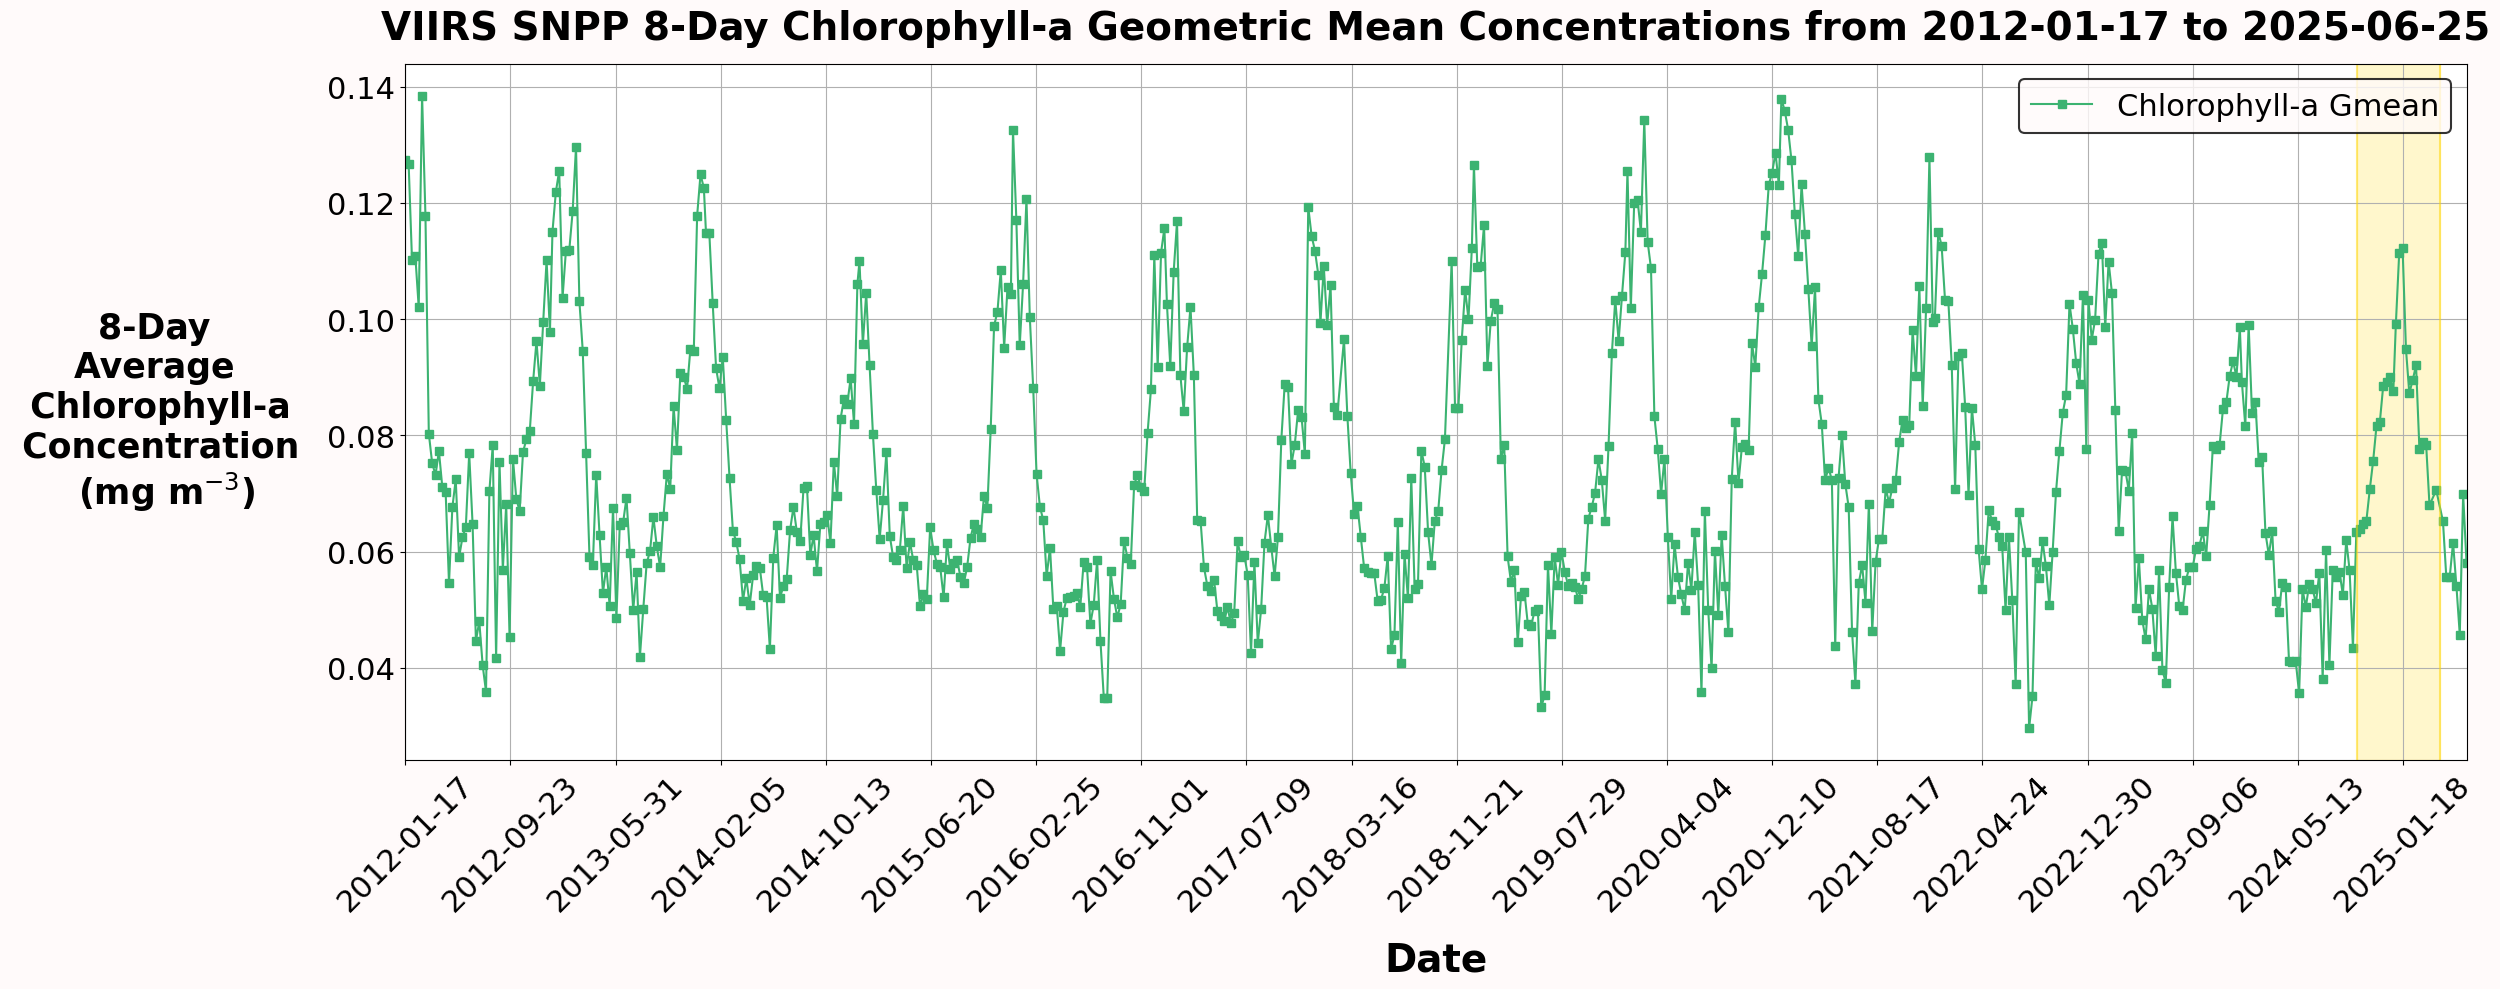

In [56]:
fig = plt.figure(figsize = (25,10), facecolor = 'snow')

# title purposes
start_idx = df['start date'].iloc[0].strftime('%Y-%m-%d')
end_idx = df['end date'].iloc[-1].strftime('%Y-%m-%d')

# plot chla_mean first
plt.plot(start_date, chla_median, linestyle = '-', color = 'firebrick', marker='s', label = 'Chlorophyll-a Median', alpha = 0.6)
plt.plot(start_date, chla_mean, linestyle = '-', color = 'navy', marker='s', label = 'Chlorophyll-a Mean', alpha = 0.6)
plt.plot(start_date, chla_gmean, linestyle = '-', color = 'mediumseagreen', marker='s', label = 'Chlorophyll-a Gmean')

# fires_start, fires_contained = '2025-01-07', '2025-01-31'
# start_toi, end_toi = '2024-10-01', '2025-04-15'
# plt.axvspan(start_toi, end_toi, color = 'gold', alpha = 0.2)
# plt.axvline(pd.to_datetime(start_toi), color='gold', linestyle='-', alpha=0.5)
# plt.axvline(pd.to_datetime(end_toi), color='gold', linestyle='-', alpha=0.5)

#plt.axvline(pd.to_datetime(start_toi), color='maroon', linestyle='--', label=f'Fires Start: {fires_start')
#plt.axvline(pd.to_datetime(end_toi), color='brown', linestyle='--', label=f'Fires Contained: {fires_end}')


plt.xlim(pd.to_datetime(start_date).min(), pd.to_datetime(start_date).max())
tick_dates = pd.date_range(start=pd.to_datetime(start_date).min(), end=pd.to_datetime(start_date).max(), freq = '25D')
plt.xticks(tick_dates[::10], rotation=45, fontsize=22)
plt.tick_params(axis = 'x', rotation=45, labelsize = 22)
plt.tick_params(axis = 'y', labelsize = 22)
plt.grid(True)
plt.ylabel('8-Day \nAverage \n Chlorophyll-a \n Concentration \n (mg m$^{-3}$)', fontsize = 25, fontweight = 'bold', rotation = 0, va = 'center', labelpad = 120)
plt.xlabel('Date', fontsize = 28, fontweight = 'bold', rotation = 0, labelpad = 18)


legend = plt.legend(fontsize = 22,loc='upper right')# bbox_to_anchor = (1, 0.5))
legend.get_frame().set_edgecolor('black')    
legend.get_frame().set_linewidth(1.5)        
legend.get_frame().set_facecolor('snow')

plt.title(f'VIIRS SNPP 8-Day Chlorophyll-a Geometric Mean Concentrations from {start_idx} to {end_idx}', fontsize = 28, fontweight = 'bold', pad = 18)
plt.tight_layout()
plt.savefig('/home/jovyan/Desktop/figures/VIIRS SNPP 8-D/updated_VIIRS 8-D L3 Chl-a Concentrations', bbox_inches='tight', dpi = 300)

### FOR ZOOMED TIMESPAN

In [14]:
# plot both
df_p = pd.read_csv('/home/jovyan/Desktop/newest datasets/chla_PACE_timeseries_8D_PACE_OCI_L3M_CHL.csv')
df_p = df_p.drop(columns = {'Unnamed: 0'})
df_p = df_p[]
df_p

,start date,end date,start year,start month,start day,end year,end month,end day,POC mean,POC geometric mean,POC median,POC std,POC geometric std,POC variance,POC N,POC IQR
0,2012-01-17,2012-01-24,2012,1,17,2012,1,24,43.109900,42.210540,40.199707,9.889736,1.215921,97.806880,23691,7.600098
1,2012-01-25,2012-02-01,2012,1,25,2012,2,1,43.325270,42.349020,39.600098,10.548812,1.222027,111.277435,26046,5.399902
2,2012-02-02,2012-02-09,2012,2,2,2012,2,9,39.947940,39.297977,37.000000,8.071814,1.187839,65.154175,26030,6.000000
3,2012-02-10,2012-02-17,2012,2,10,2012,2,17,39.922024,39.119167,36.799805,9.095243,1.210040,82.723460,25712,7.000000
4,2012-02-18,2012-02-25,2012,2,18,2012,2,25,44.967667,43.913082,41.000000,11.399781,1.225484,129.955020,21123,8.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,2025-05-17,2025-05-24,2025,5,17,2025,5,24,35.920640,35.489360,34.399902,6.092541,1.160996,37.119060,17269,5.200195
605,2025-05-25,2025-06-01,2025,5,25,2025,6,1,36.064846,35.777180,35.000000,4.882749,1.130742,23.841240,9624,4.600098
606,2025-06-02,2025-06-09,2025,6,2,2025,6,9,37.698048,37.421444,36.600098,4.765207,1.126569,22.707197,12231,5.200195
607,2025-06-10,2025-06-17,2025,6,10,2025,6,17,33.730476,33.313725,31.600098,5.870558,1.162403,34.463448,20832,4.000000


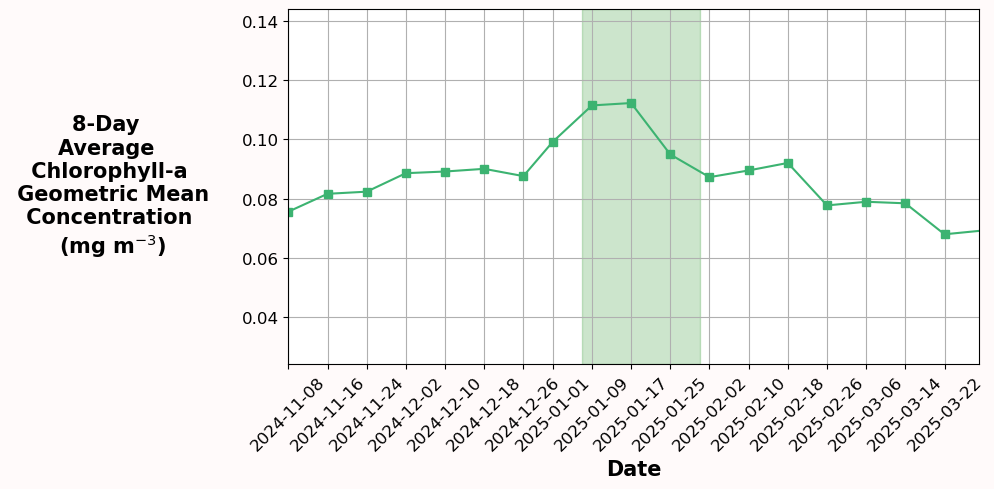

In [35]:
fig = plt.figure(figsize = (10,5), facecolor = 'snow')

# title purposes
start_idx = df['start date'].iloc[0].strftime('%Y-%m-%d')
end_idx = df['end date'].iloc[-1].strftime('%Y-%m-%d')

zoom_x_min = datetime.strptime('2024-11-08', '%Y-%m-%d')
zoom_x_max = datetime.strptime('2025-03-29', '%Y-%m-%d')


# plot chla_mean first
plt.plot(start_date, chla_median, linestyle = '-', color = 'firebrick', marker='s', label = 'Chlorophyll-a Median', alpha = 0.6)
plt.plot(start_date, chla_mean, linestyle = '-', color = 'navy', marker='s', label = 'Chlorophyll-a Mean', alpha = 0.6)
plt.plot(start_date, chla_gmean, linestyle = '-', color = 'mediumseagreen', marker='s', label = 'Chlorophyll-a Gmean')


start_toi = '2025-01-07'
end_toi = '2025-01-31'
plt.axvspan(start_toi, end_toi, color = 'green', alpha = 0.2, label = f'TOI: {start_toi} to {end_toi}')


plt.tick_params(axis = 'x', rotation=45, labelsize = 12)
plt.tick_params(axis = 'y', labelsize = 12)
plt.grid(True)
plt.ylabel('8-Day \nAverage \n Chlorophyll-a \n Geometric Mean\n Concentration \n (mg m$^{-3}$)', fontsize = 15, fontweight = 'bold', rotation = 0, va = 'center', labelpad = 95)
plt.xlabel('Date', fontsize = 15, fontweight = 'bold', rotation = 0)


plt.legend(loc='upper right', fontsize = 12)

start_date = pd.to_datetime(start_date)
tick_dates = [d for d in start_date if zoom_x_min <= d <= zoom_x_max]
plt.xticks(tick_dates, rotation=45)
plt.xlim(zoom_x_min, zoom_x_max)


start, end = tick_dates[0].strftime('%Y-%m-%d'), tick_dates[-1].strftime('%Y-%m-%d')
plt.title(f'VIIRS SNPP 8-Day Chlorophyll-a Mean, Median, and Geometric Mean Concentrations from {start} to {end}', fontsize = 19, fontweight = 'bold')

plt.tight_layout()
#plt.savefig('/home/jovyan/Desktop/figures/VIIRS SNPP 8-D/zoomed VIIRS 8-Day Chl-a Concentrations', bbox_inches = 'tight', dpi = 300)

# Plot Julian Day Data

In [10]:
# original dataset
df = pd.read_csv(r'/home/jovyan/Desktop/newest datasets/VIIRS_timeseries_8D_2012-2025.csv')
df = df.drop(columns = 'Unnamed: 0')
df = df.rename(columns = {'end_date': 'end date', 'chl-a median:': 'chl-a median'})
df['start date'], df['end date'] = pd.to_datetime(df['start date'].astype(str), format="%Y%m%d"), pd.to_datetime(df['end date'].astype(str), format="%Y%m%d")
df

,start date,end date,start year,start month,start day,end year,end month,end day,chl-a mean,chl-a geometric mean,chl-a median,chl-a std,chl-a geometric std,chl-a variance,chl-a N,chl-a IQR
0,2012-01-17,2012-01-24,2012,1,17,2012,1,24,0.133699,0.127383,0.121169,0.044651,1.355193,0.001994,23691,0.043872
1,2012-01-25,2012-02-01,2012,1,25,2012,2,1,0.133063,0.126778,0.117678,0.047394,1.340415,0.002246,26046,0.032512
2,2012-02-02,2012-02-09,2012,2,2,2012,2,9,0.114860,0.110238,0.103535,0.037004,1.313536,0.001369,26030,0.032219
3,2012-02-10,2012-02-17,2012,2,10,2012,2,17,0.116413,0.110789,0.105258,0.041623,1.348910,0.001733,25712,0.035918
4,2012-02-18,2012-02-25,2012,2,18,2012,2,25,0.115197,0.102037,0.098393,0.063475,1.616313,0.004029,21123,0.067556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
608,2025-05-17,2025-05-24,2025,5,17,2025,5,24,0.066458,0.061525,0.060268,0.030490,1.448664,0.000930,17269,0.021792
609,2025-05-25,2025-06-01,2025,5,25,2025,6,1,0.057428,0.054068,0.054706,0.021857,1.409553,0.000478,9624,0.020369
610,2025-06-02,2025-06-09,2025,6,2,2025,6,9,0.049078,0.045682,0.043493,0.021285,1.435980,0.000453,12231,0.018384
611,2025-06-10,2025-06-17,2025,6,10,2025,6,17,0.072245,0.069843,0.065213,0.021305,1.283507,0.000454,20832,0.011557


In [12]:
df['julian day start'] = df['start date'].dt.dayofyear
df['julian day end'] = df['end date'].dt.dayofyear
df

,start date,end date,start year,start month,start day,end year,end month,end day,chl-a mean,chl-a geometric mean,chl-a median,chl-a std,chl-a geometric std,chl-a variance,chl-a N,chl-a IQR,julian day start,julian day end
0,2012-01-17,2012-01-24,2012,1,17,2012,1,24,0.133699,0.127383,0.121169,0.044651,1.355193,0.001994,23691,0.043872,17,24
1,2012-01-25,2012-02-01,2012,1,25,2012,2,1,0.133063,0.126778,0.117678,0.047394,1.340415,0.002246,26046,0.032512,25,32
2,2012-02-02,2012-02-09,2012,2,2,2012,2,9,0.114860,0.110238,0.103535,0.037004,1.313536,0.001369,26030,0.032219,33,40
3,2012-02-10,2012-02-17,2012,2,10,2012,2,17,0.116413,0.110789,0.105258,0.041623,1.348910,0.001733,25712,0.035918,41,48
4,2012-02-18,2012-02-25,2012,2,18,2012,2,25,0.115197,0.102037,0.098393,0.063475,1.616313,0.004029,21123,0.067556,49,56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
608,2025-05-17,2025-05-24,2025,5,17,2025,5,24,0.066458,0.061525,0.060268,0.030490,1.448664,0.000930,17269,0.021792,137,144
609,2025-05-25,2025-06-01,2025,5,25,2025,6,1,0.057428,0.054068,0.054706,0.021857,1.409553,0.000478,9624,0.020369,145,152
610,2025-06-02,2025-06-09,2025,6,2,2025,6,9,0.049078,0.045682,0.043493,0.021285,1.435980,0.000453,12231,0.018384,153,160
611,2025-06-10,2025-06-17,2025,6,10,2025,6,17,0.072245,0.069843,0.065213,0.021305,1.283507,0.000454,20832,0.011557,161,168


In [14]:
julian_sday = df['julian day start'].values.copy()
julian_eday = df['julian day end'].values.copy()
chla_mean = df['chl-a mean'].values.copy()
chla_gmean = df['chl-a geometric mean'].values.copy()
chla_median = df['chl-a median'].values.copy()
chla_std = df['chl-a std'].values.copy()
chla_gstd = df['chl-a geometric std'].values.copy()
chla_var = df['chl-a variance'].values.copy()
chla_n = df['chl-a N'].values.copy()

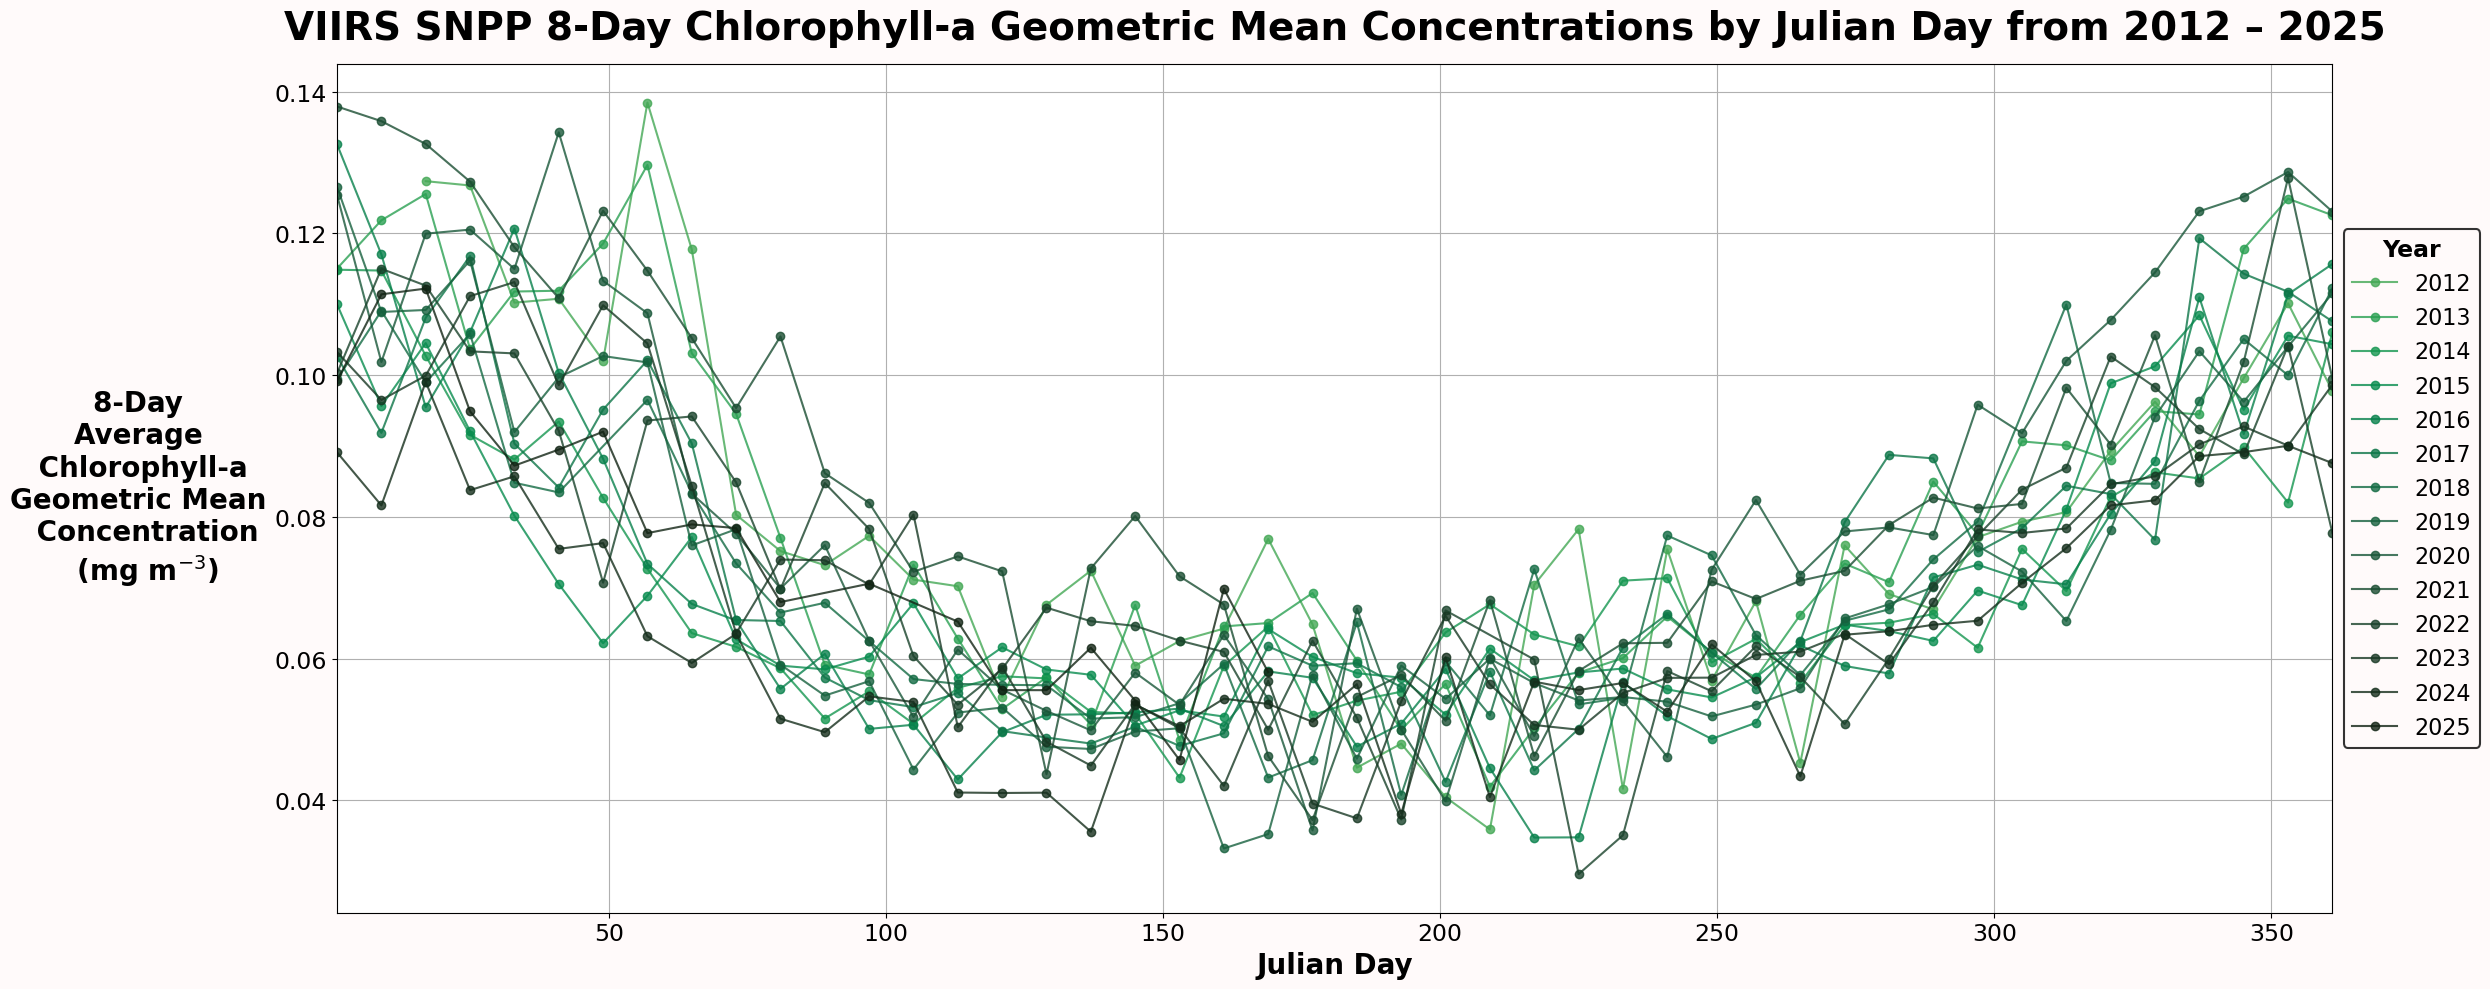

In [16]:
fig, ax = plt.subplots(figsize = (25,10), facecolor = 'snow')

colors = cmocean.cm.algae(np.linspace(0.4, 1, 14))  # for 11 years: 2015–2025   twilight_r

for i, year in enumerate(range(2012, 2026)):
    year_data = df[df['start year'] == year]
    if not year_data.empty:
        ax.plot(
            year_data['julian day start'],
            year_data['chl-a geometric mean'],  # or chla_median / chla_mean
            label=str(year),
            color=colors[i],
            marker='o',
            alpha=0.8
        )
plt.xlim(julian_sday.min(), julian_sday.max())
ax.set_xlabel('Julian Day', fontsize=20, fontweight='bold')
ax.set_ylabel('8-Day \nAverage \n Chlorophyll-a \nGeometric Mean \n Concentration\n (mg m$^{-3}$)', rotation = 0, va = 'center', fontsize=20, fontweight='bold', labelpad = 95)
ax.set_title('VIIRS SNPP 8-Day Chlorophyll-a Geometric Mean Concentrations by Julian Day from 2012 – 2025', fontsize=28, fontweight='bold', pad=18)
legend = plt.legend(title="Year", title_fontsize=17, fontsize=16, loc = 'center left', bbox_to_anchor = (1, 0.5), frameon = True)
legend.get_title().set_fontweight('bold')
legend.get_frame().set_edgecolor('black')    
legend.get_frame().set_linewidth(1.5)        
legend.get_frame().set_facecolor('snow')

ax.tick_params(axis='both', labelsize=17)
ax.grid(True)

plt.tight_layout()
#plt.savefig('/home/jovyan/Desktop/figures/VIIRS SNPP 8-D/julian day VIIRS 8-Day Geometric Mean Chl-a Concentrations', bbox_inches = 'tight', dpi = 300)

# Plot Julian Data from July(year)-1 through June(year)

In [4]:
# original dataset
df = pd.read_csv(r'/home/jovyan/Desktop/newest datasets/VIIRS_timeseries_8D_2012-2025.csv')
df = df.drop(columns = 'Unnamed: 0')
df = df.rename(columns = {'end_date': 'end date', 'chl-a median:': 'chl-a median'})
df['start date'], df['end date'] = pd.to_datetime(df['start date'].astype(str), format="%Y%m%d"), pd.to_datetime(df['end date'].astype(str), format="%Y%m%d")
df['interest date'] = df['start date'].dt.strftime('%m-%d')
df['interest'] = df['start date'].dt.dayofyear
#df[40:80]
df

,start date,end date,start year,start month,start day,end year,end month,end day,chl-a mean,chl-a geometric mean,chl-a median,chl-a std,chl-a geometric std,chl-a variance,chl-a N,chl-a IQR,interest date,interest
0,2012-01-17,2012-01-24,2012,1,17,2012,1,24,0.133699,0.127383,0.121169,0.044651,1.355193,0.001994,23691,0.043872,01-17,17
1,2012-01-25,2012-02-01,2012,1,25,2012,2,1,0.133063,0.126778,0.117678,0.047394,1.340415,0.002246,26046,0.032512,01-25,25
2,2012-02-02,2012-02-09,2012,2,2,2012,2,9,0.114860,0.110238,0.103535,0.037004,1.313536,0.001369,26030,0.032219,02-02,33
3,2012-02-10,2012-02-17,2012,2,10,2012,2,17,0.116413,0.110789,0.105258,0.041623,1.348910,0.001733,25712,0.035918,02-10,41
4,2012-02-18,2012-02-25,2012,2,18,2012,2,25,0.115197,0.102037,0.098393,0.063475,1.616313,0.004029,21123,0.067556,02-18,49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
608,2025-05-17,2025-05-24,2025,5,17,2025,5,24,0.066458,0.061525,0.060268,0.030490,1.448664,0.000930,17269,0.021792,05-17,137
609,2025-05-25,2025-06-01,2025,5,25,2025,6,1,0.057428,0.054068,0.054706,0.021857,1.409553,0.000478,9624,0.020369,05-25,145
610,2025-06-02,2025-06-09,2025,6,2,2025,6,9,0.049078,0.045682,0.043493,0.021285,1.435980,0.000453,12231,0.018384,06-02,153
611,2025-06-10,2025-06-17,2025,6,10,2025,6,17,0.072245,0.069843,0.065213,0.021305,1.283507,0.000454,20832,0.011557,06-10,161


In [5]:
seasons_df = []
# find
for i in range(2012,2025):
 #   season = df[(df["start date"] >= f"{i}-11-08") & (df["start date"] <= f"{i+1}-03-22")].copy()
    season = df[(df["start date"] >= f"{i}-06-22") & (df["start date"] <= f"{i+1}-06-30")].copy()
    seasons_df.append(season)
#seasons_df

In [6]:
# extract 2024-2025 values
szn_24_25 = df[(df['start date'] >= '2024-07-02') & (df['start date'] <= '2025-06-18')].copy()
# set a shift point to reorder the axis
shift_point = 182 # based on julian days of the year 313=9
szn_24_25['shift date'] = (szn_24_25['interest'] - shift_point) % 365
szn_24_25

,start date,end date,start year,start month,start day,end year,end month,end day,chl-a mean,chl-a geometric mean,chl-a median,chl-a std,chl-a geometric std,chl-a variance,chl-a N,chl-a IQR,interest date,interest,shift date
570,2024-07-03,2024-07-10,2024,7,3,2024,7,10,0.057548,0.056382,0.056224,0.015091,1.205849,0.000228,19935,0.009672,07-03,185,3
571,2024-07-11,2024-07-18,2024,7,11,2024,7,18,0.039940,0.038092,0.038935,0.012498,1.363416,0.000156,2468,0.013085,07-11,193,11
572,2024-07-19,2024-07-26,2024,7,19,2024,7,26,0.061997,0.060185,0.059585,0.015743,1.273820,0.000248,8401,0.010997,07-19,201,19
573,2024-07-27,2024-08-03,2024,7,27,2024,8,3,0.043132,0.040450,0.038770,0.015906,1.428388,0.000253,10786,0.024094,07-27,209,27
574,2024-08-04,2024-08-11,2024,8,4,2024,8,11,0.057702,0.056741,0.056397,0.010823,1.199930,0.000117,13986,0.012021,08-04,217,35
575,2024-08-12,2024-08-19,2024,8,12,2024,8,19,0.057895,0.055550,0.054918,0.020573,1.311927,0.000423,21986,0.009483,08-12,225,43
576,2024-08-20,2024-08-27,2024,8,20,2024,8,27,0.058472,0.056557,0.053843,0.020491,1.254387,0.000420,25782,0.008790,08-20,233,51
577,2024-08-28,2024-09-04,2024,8,28,2024,9,4,0.056842,0.052478,0.051309,0.034045,1.412071,0.001159,18149,0.012032,08-28,241,59
578,2024-09-05,2024-09-12,2024,9,5,2024,9,12,0.065881,0.061995,0.058202,0.038057,1.324939,0.001448,24382,0.008322,09-05,249,67
579,2024-09-13,2024-09-20,2024,9,13,2024,9,20,0.060616,0.056794,0.053585,0.031487,1.366252,0.000991,25284,0.013750,09-13,257,75


In [7]:
# combine all non-2025 seasons into one DataFrame
df_all = pd.concat(seasons_df)
df_all['shift date'] = (df_all['interest'] - shift_point) % 365
df_all

,start date,end date,start year,start month,start day,end year,end month,end day,chl-a mean,chl-a geometric mean,chl-a median,chl-a std,chl-a geometric std,chl-a variance,chl-a N,chl-a IQR,interest date,interest,shift date
20,2012-06-25,2012-07-02,2012,6,25,2012,7,2,0.066676,0.064810,0.063305,0.020574,1.248910,0.000423,24504,0.011793,06-25,177,360
21,2012-07-03,2012-07-10,2012,7,3,2012,7,10,0.045933,0.044601,0.045816,0.010926,1.281724,0.000119,8928,0.013335,07-03,185,3
22,2012-07-11,2012-07-18,2012,7,11,2012,7,18,0.053239,0.047986,0.047273,0.034928,1.525994,0.001220,7275,0.026971,07-11,193,11
23,2012-07-19,2012-07-26,2012,7,19,2012,7,26,0.042944,0.040431,0.040563,0.018916,1.388084,0.000358,3829,0.015617,07-19,201,19
24,2012-07-27,2012-08-03,2012,7,27,2012,8,3,0.037643,0.035873,0.037401,0.011104,1.379206,0.000123,2785,0.015943,07-27,209,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
608,2025-05-17,2025-05-24,2025,5,17,2025,5,24,0.066458,0.061525,0.060268,0.030490,1.448664,0.000930,17269,0.021792,05-17,137,320
609,2025-05-25,2025-06-01,2025,5,25,2025,6,1,0.057428,0.054068,0.054706,0.021857,1.409553,0.000478,9624,0.020369,05-25,145,328
610,2025-06-02,2025-06-09,2025,6,2,2025,6,9,0.049078,0.045682,0.043493,0.021285,1.435980,0.000453,12231,0.018384,06-02,153,336
611,2025-06-10,2025-06-17,2025,6,10,2025,6,17,0.072245,0.069843,0.065213,0.021305,1.283507,0.000454,20832,0.011557,06-10,161,344


In [8]:
# compute mean and std across shift date
mean_chla = df_all.groupby('shift date')['chl-a geometric mean'].mean()
std_chla = df_all.groupby('shift date')['chl-a geometric mean'].std()

In [9]:
mean_chla

shift date
3      0.053948
11     0.050312
19     0.054751
27     0.053889
35     0.054736
43     0.054205
51     0.055495
59     0.061085
67     0.060442
75     0.061447
83     0.059443
91     0.067382
99     0.068499
107    0.072894
115    0.075938
123    0.078394
131    0.084050
139    0.088642
147    0.092975
155    0.098944
163    0.100578
171    0.106972
179    0.104953
184    0.112020
192    0.107804
200    0.109314
208    0.105637
216    0.099240
224    0.095722
232    0.094576
240    0.092878
248    0.082051
256    0.074215
264    0.067687
272    0.065017
280    0.062720
288    0.059638
296    0.056044
304    0.055583
312    0.052771
320    0.053046
328    0.056797
336    0.052522
344    0.055827
352    0.054693
360    0.052769
Name: chl-a geometric mean, dtype: float64

In [10]:
# chatgpt helped here
year_start = 2024
def shift_to_date(shift_dates, shift_point=313, year_start=2024):
    # shift_dates is array-like (e.g., mean_chla.index)
    dates = []
    for sd in shift_dates:
        # Reverse the shift:
        orig_julian = (sd + shift_point) % 365
        # If original julian >= shift_point, date is in year_start
        if orig_julian >= shift_point:
            date = pd.Timestamp(f"{year_start}-01-01") + pd.Timedelta(days=orig_julian - 1)
        else:
            # Else in next year
            date = pd.Timestamp(f"{year_start + 1}-01-01") + pd.Timedelta(days=orig_julian - 1)
        dates.append(date)
    return dates

# Get all dates for your x-axis index
x_dates = shift_to_date(mean_chla.index, shift_point=shift_point, year_start=year_start)

# Format to MM-DD strings for x-tick labels
x_labels = [d.strftime('%m-%d') for d in x_dates]

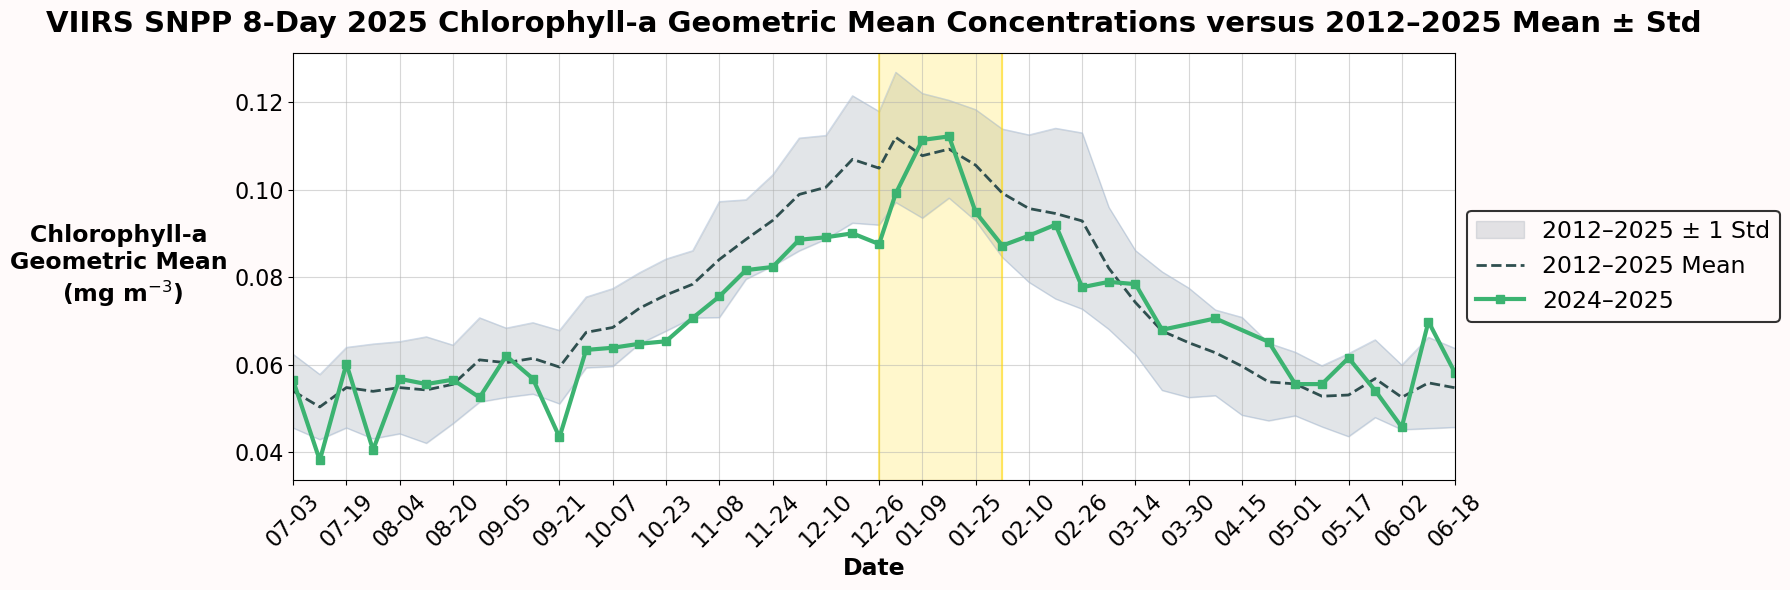

In [22]:
plt.figure(figsize=(18, 6), facecolor='snow') # for zoomed into nov 11-08 through 03-22
#plt.figure(figsize=(22, 6), facecolor='snow')
# plot shaded std deviation area
plt.fill_between(mean_chla.index, mean_chla - std_chla, mean_chla + std_chla, color='slategrey', alpha=0.2, label='2012–2025 ± 1 Std')
plt.plot(mean_chla.index, mean_chla - std_chla, color='lightsteelblue', linewidth=0.8, alpha=0.5)
plt.plot(mean_chla.index, mean_chla + std_chla, color='lightsteelblue', linewidth=0.8, alpha=0.5)
plt.axvspan(mean_chla.index[22], mean_chla.index[27], color = 'gold', alpha = 0.2)
plt.axvline(mean_chla.index[22], color='gold', linestyle='-', alpha=0.5)
plt.axvline(mean_chla.index[27], color='gold', linestyle='-', alpha=0.5)

# plot multi-year mean
plt.plot(mean_chla.index, mean_chla, color='darkslategrey', linestyle='--', linewidth=2, label='2012–2025 Mean')

# plot 2025 
plt.plot(szn_24_25['shift date'], szn_24_25['chl-a geometric mean'], color='mediumseagreen', marker='s', linewidth=3, label='2024–2025')

# set legend info
legend = plt.legend(loc='center left', fontsize=17, bbox_to_anchor=(1, 0.5))
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_facecolor('snow')

xticks = mean_chla.index[::2]
plt.xticks(xticks, [x_labels[list(mean_chla.index).index(x)] for x in xticks], rotation=45, fontsize=14)
plt.xlim(xticks.min(),xticks.max())

plt.tick_params(axis='both', labelsize=16)
plt.xlabel('Date', fontweight='bold', fontsize=17)
plt.ylabel('Chlorophyll-a \nGeometric Mean \n(mg m$^{-3}$)', fontweight='bold', fontsize=17, rotation=0, va = 'center', labelpad=80)
plt.title('VIIRS SNPP 8-Day 2025 Chlorophyll-a Geometric Mean Concentrations versus 2012–2025 Mean ± Std', fontweight='bold', fontsize=21, pad=15)

plt.grid(True, alpha=0.5, zorder=1)
plt.tight_layout()

plt.savefig('/home/jovyan/Desktop/figures/VIIRS SNPP 8-D/highlighted julian day VIIRS 8-Day Geometric Mean Chl-a Concentrations', bbox_inches = 'tight', dpi = 300)

# Plot January --> December Data in Bar Format

In [ ]:
# for each year, get every month and make a bar plot stacking the data
df_seasonality = df.groupby(['start year','start month']).mean(numeric_only=True)
df_seasonality.reset_index(inplace=True)
#df_seasonality

In [ ]:
df_seasonality = df_seasonality.drop(columns=['end year', 'end day', 'start day', 'end month'])
df_seasonality['start month'] = pd.to_datetime(df_seasonality['start month'], format = '%m').dt.strftime('%B')
#df_seasonality

In [ ]:
years = df_seasonality['start year'].unique()
months = df_seasonality['start month'].unique()

dfp = df_seasonality.pivot(index='start year', columns='start month', values='chl-a geometric mean').fillna(0)

dfp = dfp[[m for m in months if m in dfp.columns]]
dfp

In [ ]:
fig, ax = plt.subplots(figsize=(20, 8), facecolor='snow')
# set the bottom and multiply the length of the pivoted df to get an index and to stack all the bars on top of each other
bottom = [0] * len(dfp)
x = dfp.index # x is this index object

colors = {
    'January': 'royalblue',
    'February': 'lightblue',
    'March': 'seagreen',
    'April': 'palegreen',
    'May': 'orchid',
    'June': 'lightcoral',
    'July': 'mediumpurple',
    'August': 'khaki',
    'September': 'teal',
    'October': 'darksalmon',
    'November': 'slategrey',
    'December': 'rosybrown'
}


for i, month in enumerate(dfp.columns):
    heights = dfp[month].values
    bars = ax.bar(x, heights, bottom=bottom, label=month, color=colors[month], edgecolor='black', zorder = 2)
    
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + height/2,
                    f'{height:.4f}', ha='center', va='center', fontsize=10)
    
    bottom = [b + h for b, h in zip(bottom, heights)]

ax.set_ylabel('Sum of Yearly Chlorophyll-a Geometric Mean Values (mg m$^{-3}$)', fontsize = 15, fontweight = 'bold')
ax.set_xlabel('Year', fontsize = 15, fontweight = 'bold')
ax.set_title('VIIRS SNPP Monthly Chlorophyll-a Geometric Mean Values by Year', fontsize = 20, fontweight = 'bold')
legend = ax.legend(title='Month', loc='upper right', title_fontsize = 14, fontsize = 14)
legend.get_title().set_fontweight('bold')
plt.xticks(x, fontsize = 15)
plt.yticks(fontsize = 15)
plt.grid(True, alpha=0.6, zorder = 0)
plt.tight_layout()
plt.savefig('/home/jovyan/Desktop/figures/VIIRS SNPP 8-D/GMean month by year', bbox_inches = 'tight', dpi = 300)

## Only January

In [ ]:
df_avg = df.loc[df['start month'] == 1]
df_avg = df_avg.drop(columns=['end year', 'end day', 'start day', 'end month'])
df_avg = df_avg.groupby(['start year', 'start month']).mean(numeric_only=True)
df_avg.reset_index(inplace=True)
df_avg

In [ ]:
chl_a_avg = df_avg['chl-a geometric mean'].values
start_year = df_avg['start year'].values
variable = 'Geometric Mean'

fig = plt.figure(figsize = (15,5), facecolor = 'snow')
#plt.bar(start_year, chl_a_avg, width = 0.8, color='mediumseagreen')
bars = plt.bar(start_year, chl_a_avg, color='mediumseagreen', edgecolor='black')
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,  
        height + 0,                    
        f'{height:.4f}',                  
        ha='center', va='bottom'  # horizontally center, align to bottom
    )
plt.tick_params(axis = 'x', rotation=0, labelsize = 11)
plt.tick_params(axis = 'y', labelsize = 11)
plt.grid(True, alpha = 0.5)
plt.ylabel(f'Chlorophyll-a {variable} (mg m$^{-3}$)', fontsize = 13, fontweight = 'bold') #rotation = 0, labelpad = 130)
plt.xlabel('Date', fontsize = 13, fontweight = 'bold', rotation = 0)
plt.xticks(start_year)
plt.title(f'VIIRS SNPP 8-Day Chlorophyll-a {variable} January Concentrations from 2015 to 2025', fontsize = 15, fontweight = 'bold', pad = 20)
plt.savefig(f'/home/jovyan/Desktop/figures/VIIRS Chl-a Jan {variable} Concentrations', bbox_inches = 'tight', dpi = 300)

## Line plot

In [ ]:
# line plot
fig, ax = plt.subplots(figsize=(20, 8), facecolor='snow')
x_all = dfp.index  # full list of years

colors = {
    'January': 'royalblue',
    'February': 'lightblue',
    'March': 'seagreen',
    'April': 'palegreen',
    'May': 'orchid',
    'June': 'lightcoral',
    'July': 'mediumpurple',
    'August': 'khaki',
    'September': 'teal',
    'October': 'darksalmon',
    'November': 'slategrey',
    'December': 'rosybrown'
}

for month in dfp.columns:
    # Filter out missing or zero values
    month_data = dfp[month]
    valid_mask = month_data > 0  # Or use ~month_data.isna() if you prefer
    x = dfp.index[valid_mask]
    y = month_data[valid_mask]

    if len(x) == 0:
        continue  # skip months with no data at all

    ax.plot(x, y, label=month, color=colors[month], marker='o', linewidth=2, zorder=3)

    # Add point labels
    for xi, yi in zip(x, y):
        ax.text(xi, yi + 0.002, f'{yi:.4f}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Monthly Chlorophyll-a Geometric Mean (mg m$^{-3}$)', fontsize=15, fontweight='bold')
ax.set_xlabel('Year', fontsize=15, fontweight='bold')
ax.set_title('VIIRS SNPP Monthly Chlorophyll-a Geometric Mean Values by Year', fontsize=20, fontweight='bold')
legend = ax.legend(title='Month', bbox_to_anchor=(1, 1), loc='upper left', title_fontsize=14, fontsize=14)
legend.get_title().set_fontweight('bold')
plt.xticks(x_all, fontsize=13)
plt.yticks(fontsize=13)
plt.grid(True, alpha=0.6, zorder=0)
plt.tight_layout()
plt.savefig('/home/jovyan/Desktop/figures/VIIRS SNPP 8-D/GMean_lineplot_month.png', bbox_inches='tight', dpi=300)